# Worksheet 1 — Image Understanding and Compression with PCA



## Import Required Libraries

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

## Exercise 1 — Basic Image Processing

### 1. Read and Display Image

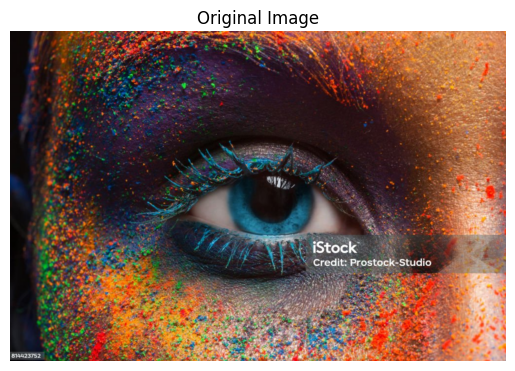

In [10]:
image = Image.open("/eye.png")
image_array = np.array(image)

plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

### 2. Display Top Left 100x100 Pixels

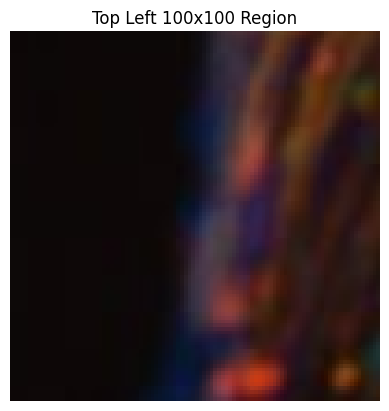

In [11]:
top_left = image_array[:100, :100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Region")
plt.axis("off")
plt.show()

### 3. Display RGB Channels

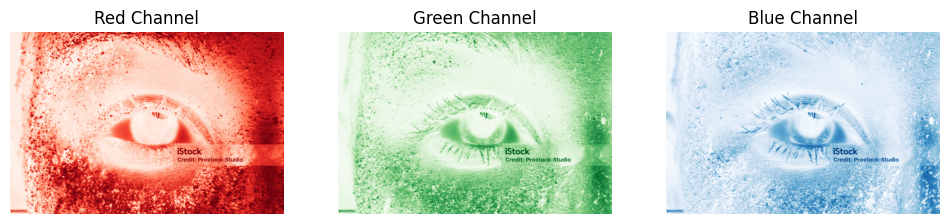

In [12]:
R = image_array[:,:,0]
G = image_array[:,:,1]
B = image_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(R, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

### 4. Modify Top Left 100x100 Pixels

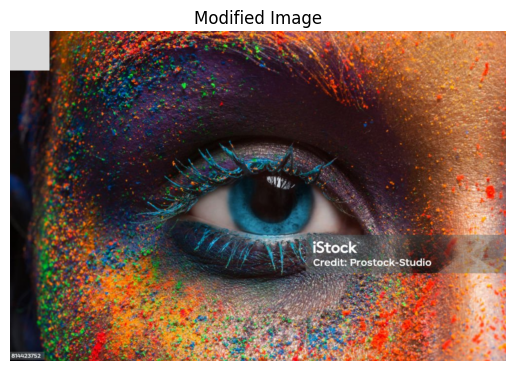

In [13]:
modified = image_array.copy()
modified[:100, :100] = 210

plt.imshow(modified)
plt.title("Modified Image")
plt.axis("off")
plt.show()

## Exercise 2 — Grayscale Image Processing

### 1. Load Grayscale Image

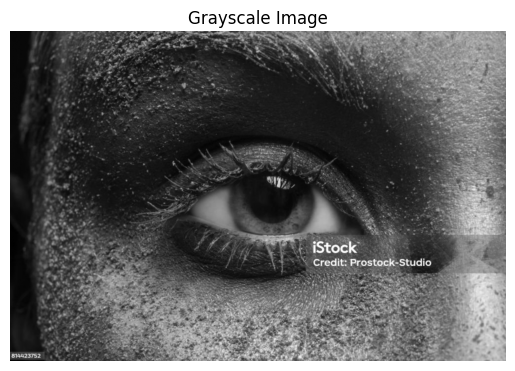

In [15]:
gray_image = Image.open("/eye.png").convert("L")
gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

### 2. Extract Center 150x150 Section

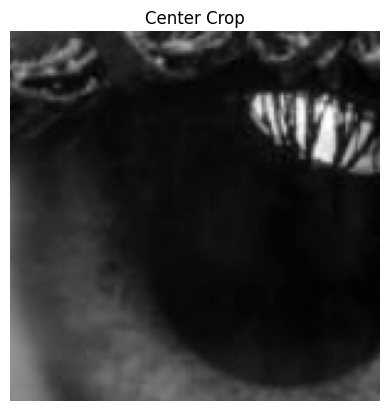

In [16]:
h, w = gray_array.shape
center = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap="gray")
plt.title("Center Crop")
plt.axis("off")
plt.show()

### 3. Apply Threshold

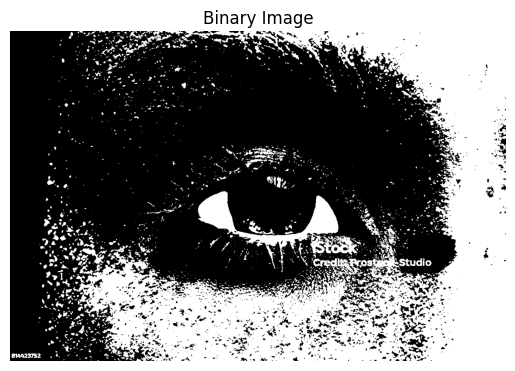

In [17]:
binary = gray_array.copy()
binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

### 4. Rotate Image 90° Clockwise

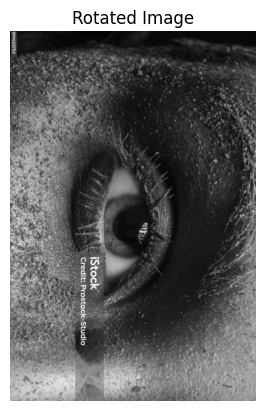

In [18]:
rotated = np.rot90(gray_array, -1)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image")
plt.axis("off")
plt.show()

### 5. Convert Grayscale to RGB

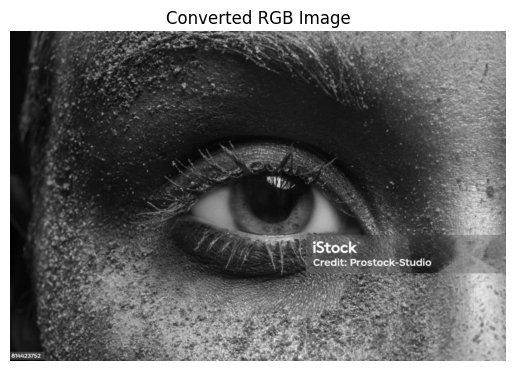

In [19]:
rgb_image = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Converted RGB Image")
plt.axis("off")
plt.show()

## Exercise 3 — Image Compression Using PCA

### Step 1: Load Image

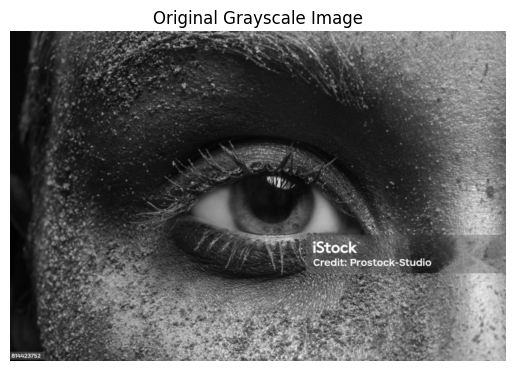

In [24]:
img = Image.open("/eye.png").convert("L")
img = np.array(img)

plt.imshow(img, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

### Step 2: Center Data

In [25]:
mean = np.mean(img, axis=0)
centered = img - mean

### Step 3: Covariance Matrix

In [26]:
cov_matrix = np.cov(centered, rowvar=False)

### Step 4: Eigen Decomposition

In [27]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

### Step 5: Sort Eigenvalues

In [28]:
sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

### Step 6: Select Principal Components

In [29]:
k = 50
principal_components = eigenvectors[:, :k]

### Step 7: Compress Image

In [30]:
compressed = np.dot(centered, principal_components)

### Step 8: Reconstruct Image

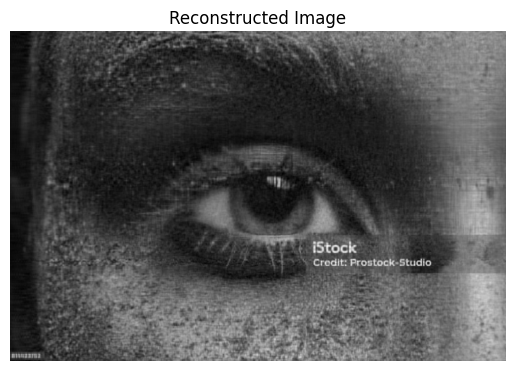

In [31]:
reconstructed = np.dot(compressed, principal_components.T) + mean

plt.imshow(reconstructed, cmap="gray")
plt.title("Reconstructed Image")
plt.axis("off")
plt.show()

### Step 9: Compare Multiple Principal Components

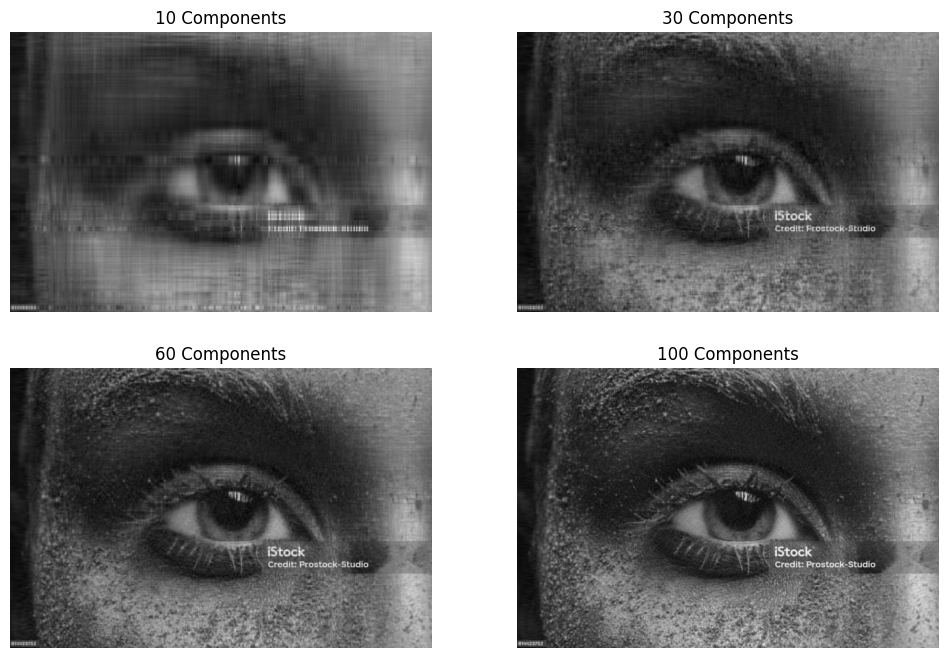

In [32]:
components = [10,30,60,100]

plt.figure(figsize=(12,8))

for i,k in enumerate(components):
    pcs = eigenvectors[:, :k]
    comp = np.dot(centered, pcs)
    recon = np.dot(comp, pcs.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(recon, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.show()